Trying to reproduce phase diagrams from: 

- [Quantum correlations, entanglement spectrum and coherence of two-particle reduced density matrix in the Extended Hubbard Model](https://arxiv.org/pdf/2111.00085)

- [Formation of spin and charge ordering in the extended Hubbard model during a finite-time quantum quench](https://arxiv.org/pdf/2208.05945)


- [Entanglement of indistinguishable particles as a probe for quantum phase transitions in the extended Hubbard model](https://arxiv.org/pdf/1503.08188)

In [260]:
from __future__ import print_function, division
import sys,os
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
import pandas as pd
import ast


%matplotlib inline 

font = {
        'weight' : 'bold',
        'size'   : 16}
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('font', **font) 

figures_path = "../figs"
model = "EHM_Itensor" 
exec = "Phase_Diagram"
results = "../results"

U_max = 6.0
V_max = 4.0

N_Points = 50
L = 5

'''
        L = 6, N_Points = 80
'''

'\n        L = 6, N_Points = 80\n'

In [256]:
# Order parameters
def m_SDW(L, Sj): 
    m_sdw = 0
    for j in range(L):
        m_sdw += (-1)**(j) * (Sj[j])
    return m_sdw / L

def m_CDW(L, nj):
    m_cdw = 0
    for j in range(L):
        m_cdw += (-1)**(j) * (nj[j] - 1)
    return m_cdw / L 

In [ ]:
info_input = f"{results}/{model}_{exec}/scalars_{model}_L={L}_NPoints={N_Points}.csv"
df = pd.read_csv(info_input)

info_input = f"{results}/{model}_{exec}/vector_measures_{model}_L={L}_NPoints={N_Points}.csv"
df_vecs = pd.read_csv(info_input)

U_unique = np.sort(df['U'].unique())
V_unique = np.sort(df['V'].unique())

U_vals = U_unique
V_vals = V_unique

U_min, U_max = U_vals.min(), U_vals.max()
V_min, V_max = V_vals.min(), V_vals.max()

nU = len(U_vals)
nV = len(V_vals)

avg_linear_entropy = df['S'].values.reshape(nV, nU)
quantum_coherence = df['Coh'].values.reshape(nV, nU)
E_p = df['E_p'].values.reshape(nV, nU)
E_p_bits = df['E_p_bits'].values.reshape(nV, nU)
E_GS = df['E_GS'].values.reshape(nV, nU)

m_sdw = df['m_sdw'].values.reshape(nV, nU)
m_cdw = df['m_cdw'].values.reshape(nV, nU)

U_unique = np.sort(df['U'].unique())
V_unique = np.sort(df['V'].unique())

U_vals = U_unique
V_vals = V_unique

U_min, U_max = U_vals.min(), U_vals.max()
V_min, V_max = V_vals.min(), V_vals.max()

nU = len(U_vals)
nV = len(V_vals)

# Loading the 1-dimensional data frame values. 

def parse_array(cell):
    return np.fromstring(cell.replace(";;", "").replace(";", ","), sep=",")

# Apply parsing
df_vecs["magnetization"] = df_vecs["magnetization"].apply(parse_array)
df_vecs["charge_density"] = df_vecs["charge_density"].apply(parse_array)

magnetization = np.zeros((nV, nU, L))
charge_density = np.zeros((nV, nU, L))

# thanks gpt
for _, row in df_vecs.iterrows():
    i = np.where(V_unique == row["V"])[0][0]
    j = np.where(U_unique == row["U"])[0][0]
    magnetization[i, j] = row["magnetization"]
    charge_density[i, j] = row["charge_density"]

Don't know why, but this order parameters computed in the julia code give the wrong $|m_SDW|$ and $|m_CDW|$...
Saving the magnetization and charge density made possible to compute in python.

In [262]:
m_sdw = np.zeros((N_Points, N_Points))
m_cdw = np.zeros((N_Points, N_Points))

for i in range(U_vals.shape[0]):
    for j in range(V_vals.shape[0]):
        m_sdw[i, j] = np.abs(m_SDW(L, magnetization[i, j]))
        m_cdw[i, j] = np.abs(m_CDW(L, charge_density[i, j]))

### Order parameters for spin-density wave and charge-density wave

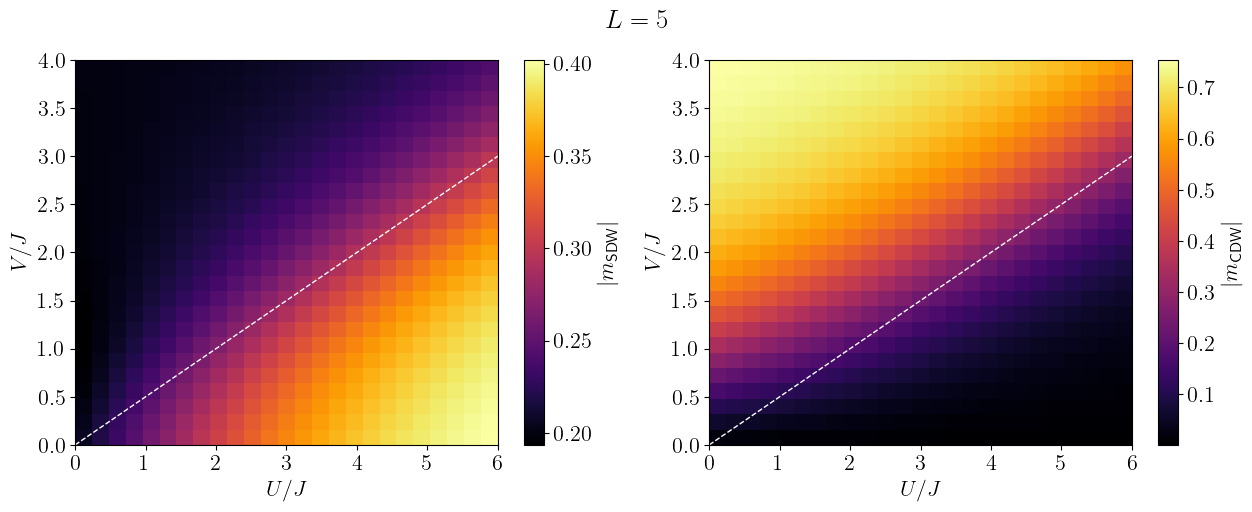

In [263]:
U_min_plot, U_max_plot = 0 , U_max
V_min_plot, V_max_plot = 0 , V_max

def select_region(U_vals, V_vals, data, U_min_plot, U_max_plot, V_min_plot, V_max_plot):
    U_mask = (U_vals >= U_min_plot) & (U_vals <= U_max_plot)
    V_mask = (V_vals >= V_min_plot) & (V_vals <= V_max_plot)
    return U_vals[U_mask], V_vals[V_mask], data[np.ix_(V_mask, U_mask)]

# Slice arrays
U_vals_plot, V_vals_plot, m_sdw_plot = select_region(U_vals, V_vals, m_sdw, U_min_plot, U_max_plot, V_min_plot, V_max_plot)
_, _, m_cdw_plot = select_region(U_vals, V_vals, m_cdw, U_min_plot, U_max_plot, V_min_plot, V_max_plot)

# Meshgrid for contours
X, Y = np.meshgrid(U_vals_plot, V_vals_plot)

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
plt.suptitle(f"$L = {L}$")

# m_SDW
im0 = ax[0].imshow(np.abs(m_sdw_plot), origin="lower", extent=[U_min_plot, U_max_plot, V_min_plot, V_max_plot], aspect="auto", cmap="inferno")
fig.colorbar(im0, ax=ax[0], label=r"$|m_{\text{SDW}}|$")
# ax[0].contour(X, Y, np.abs(m_sdw_plot), colors='white', linestyle='--', linewidths=0.7)
ax[0].set_xlabel(r"$U / J$")
ax[0].set_ylabel(r"$V / J$")

# m_CDW
im1 = ax[1].imshow(np.abs(m_cdw_plot), origin="lower", extent=[U_min_plot, U_max_plot, V_min_plot, V_max_plot], aspect="auto", cmap="inferno")
fig.colorbar(im1, ax=ax[1], label=r"$|m_{\text{CDW}}|$")
# ax[1].contour(X, Y, np.abs(m_cdw_plot), colors='white', linestyle='--', linewidths=0.7)
ax[1].set_xlabel(r"$U / J$")
ax[1].set_ylabel(r"$V / J$")

# Line U = 2V
V_range = np.linspace(max(0, V_min_plot), min(U_max_plot / 2, V_max_plot), N_Points)
U_range = 2 * V_range
ax[0].plot(U_range, V_range, 'w--', linewidth=1)
ax[1].plot(U_range, V_range, 'w--', linewidth=1)

# Save and show
plt.savefig(f"{figures_path}/{model}_{exec}/order_parameters_L={L}_U={U_min_plot}-{U_max_plot}_V={V_min_plot}-{V_max_plot}.png", dpi=300, bbox_inches="tight")
plt.show()

#### Energy

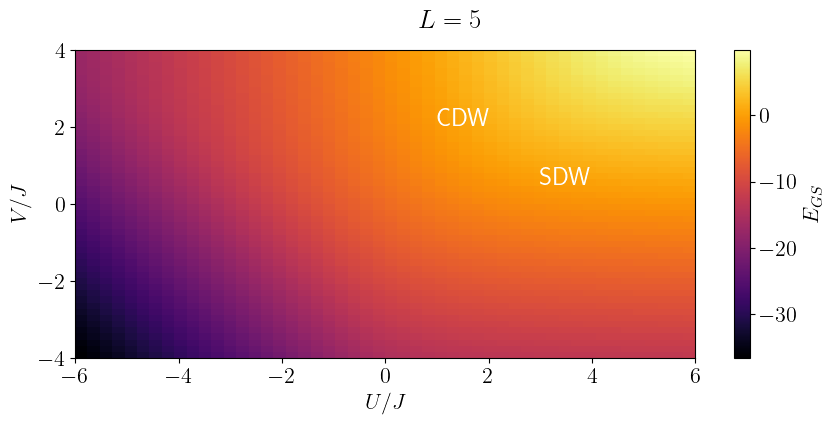

In [264]:
# Create a figure with two subplots
fig, ax = plt.subplots(1, 1, figsize=(10, 4), sharex=True)
    
im0 = ax.imshow(E_GS, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap="inferno")
fig.colorbar(im0, ax=ax, label=r"$E_{GS}$")
ax.set_xlabel(r"$U / J$")
ax.set_ylabel(r"$V / J$")

# Plot line U = 2V
# V_range = np.linspace(0, U_max / 2, N_Points)
# U_range = 2 * V_range 
# ax.plot(U_range, V_range, 'w--', linewidth=1)  
    
ax.text(1, 2, "$\\text{CDW}$", color = "white", fontsize=18)
ax.text(3, 0.5, "$\\text{SDW}$", color = "white", fontsize=18)
    
plt.suptitle(f"$L = {L}$")
plt.show()
fig.savefig(f"{figures_path}/{model}_{exec}/E_GS={L}_{model}_NPoints={N_Points}.png", dpi = 500, bbox_inches='tight')

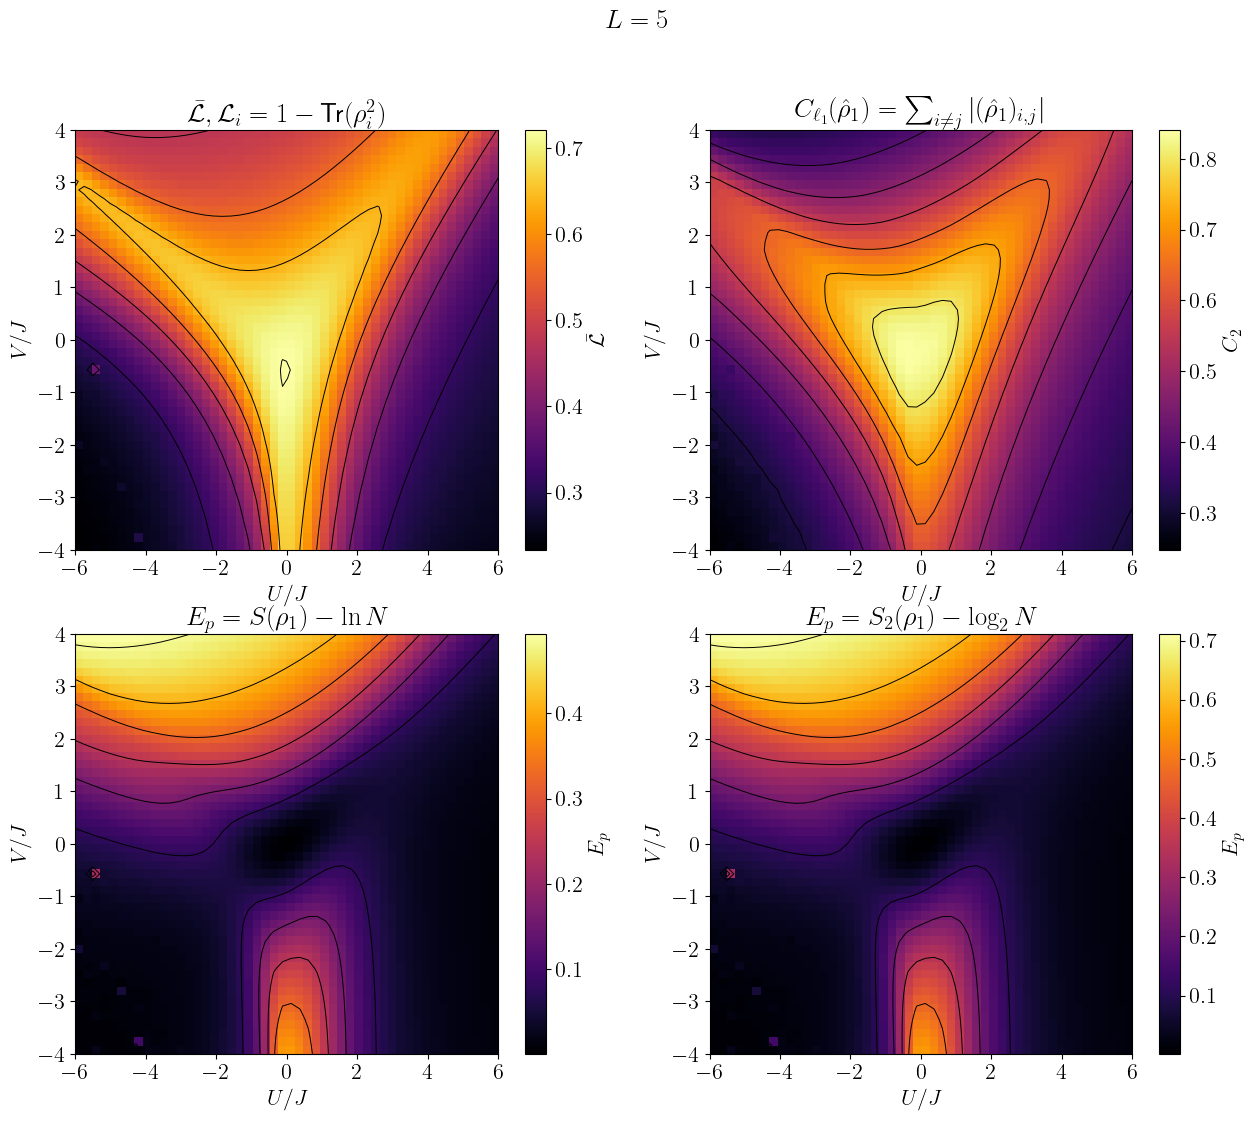

In [265]:
# Create a figure with two subplots
fig, ax1 = plt.subplots(2, 2, figsize=(15, 12))
plt.suptitle(f"$L = {L}$")

# Shared colorbar normalization - thanks chatgpt
# vmin = min(np.min(avg_linear_entropy), np.min(E_p))
# vmax = max(np.max(avg_linear_entropy), np.max(E_p))

U_min = np.min(U_vals)
U_max = np.max(U_vals)
V_min = np.min(V_vals)
V_max = np.max(V_max)

# E_p = E_p / np.max(E_p) 
# avg_linear_entropy = avg_linear_entropy / np.max(avg_linear_entropy)

# Contour 
X, Y = np.meshgrid(U_vals, V_vals)

im0 = ax1[0, 0].imshow(avg_linear_entropy, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap="inferno")# , vmin=vmin, vmax=vmax)
fig.colorbar(im0, ax = ax1[0, 0], orientation='vertical', label=r"$\bar{\mathcal{L}}$") # /\text{max}(\bar{\mathcal{L}})$")

ax1[0, 0].contour(X, Y, avg_linear_entropy, colors='black', linewidths=0.7)

im2 = ax1[0, 1].imshow(quantum_coherence, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap="inferno") #  , vmin=vmin, vmax=vmax)
fig.colorbar(im2, ax = ax1[0, 1], orientation='vertical',  label=r"$C_2$")
ax1[0, 1].contour(X, Y, quantum_coherence, colors='black', linewidths=0.7)

im1 = ax1[1, 0].imshow(E_p, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap="inferno") #  , vmin=vmin, vmax=vmax)
fig.colorbar(im1, ax = ax1[1, 0], orientation='vertical',  label=r"$E_p$") #  / \text{max}(E_{p})$")
ax1[1, 0].contour(X, Y, E_p, colors='black', linewidths=0.7)

im1 = ax1[1, 1].imshow(E_p_bits, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap="inferno") #  , vmin=vmin, vmax=vmax)
fig.colorbar(im1, ax = ax1[1, 1], orientation='vertical',  label=r"$E_p$") #  / \text{max}(E_{p})$")
ax1[1, 1].contour(X, Y, E_p, colors='black', linewidths=0.7)

# bar = plt.colorbar(im0, orientation='vertical', shrink=0.8, label=r"$E_p$") 
ax1[0, 0].set_xlabel(r"$U / J$")
ax1[0, 0].set_ylabel(r"$V / J$")

ax1[1, 0].set_xlabel(r"$U / J$")
ax1[1, 0].set_ylabel(r"$V / J$")

ax1[0, 1].set_xlabel(r"$U / J$")
ax1[0, 1].set_ylabel(r"$V / J$")

ax1[1, 1].set_xlabel(r"$U / J$")
ax1[1, 1].set_ylabel(r"$V / J$")

ax1[0, 0].set_title(r"$\bar{\mathcal{L}}, \mathcal{L}_i = 1 - \text{Tr}(\rho_i^2)$")
ax1[0, 1].set_title(r"$C_{\ell_1}(\hat{\rho}_1) = \sum_{i\neq j}|(\hat{\rho}_1)_{i, j}|$")
ax1[1, 0].set_title(r"$E_p = S(\rho_1) - \ln N$")
ax1[1, 1].set_title(r"$E_p = S_2(\rho_1) - \log_2 N$")

fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_entropy_1_RDM_L={L}_NPoints={N_Points}.png", dpi=100, bbox_inches='tight')
plt.show()

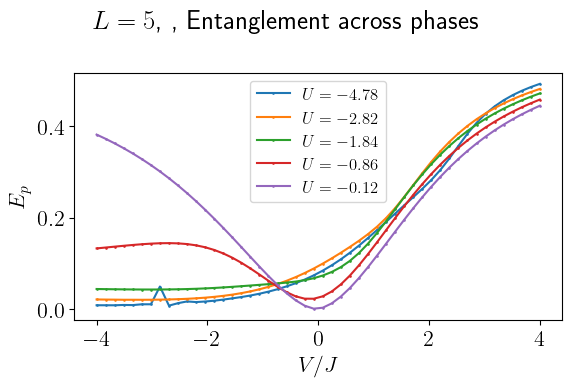

In [266]:
U_targets = [-4.75, -2.85, -1.76, -0.95, 0.0]

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plt.suptitle(f"$L = {L}$, , Entanglement across phases")

for U_target in U_targets:
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax.plot(V_vals, E_p[:, i_U_fixed], 'o-', markersize=0.9,  label=fr"$U={U_vals[i_U_fixed]:.2f}$")

ax.set_xlabel(r"$V / J$")
ax.set_ylabel(r"$E_p$")
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

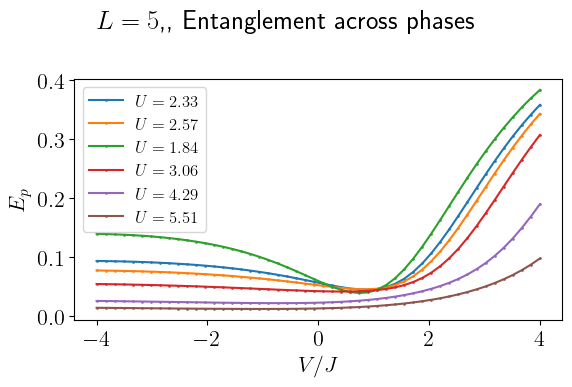

In [267]:
U_targets = [2.3, 2.6, 1.9, 3.1, 4.3, 5.6]

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plt.suptitle(f"$L = {L}$,, Entanglement across phases")

for U_target in U_targets:
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax.plot(V_vals, E_p[:, i_U_fixed], 'o-', markersize=0.9,  label=fr"$U={U_vals[i_U_fixed]:.2f}$")

# ax.set_xlim(0, 4)

ax.set_xlabel(r"$V / J$")
ax.set_ylabel(r"$E_p$")
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

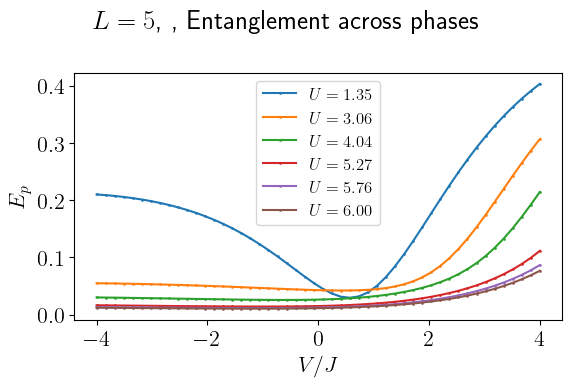

In [268]:
U_targets = [1.36, 3.15, 4.0, 5.3, 5.7,  6.0]

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plt.suptitle(f"$L = {L}$, , Entanglement across phases")

for U_target in U_targets:
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax.plot(V_vals, E_p[:, i_U_fixed], 'o-', markersize=0.9,  label=fr"$U={U_vals[i_U_fixed]:.2f}$")

# ax.set_xlim(0, 4)

ax.set_xlabel(r"$V / J$")
ax.set_ylabel(r"$E_p$")
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

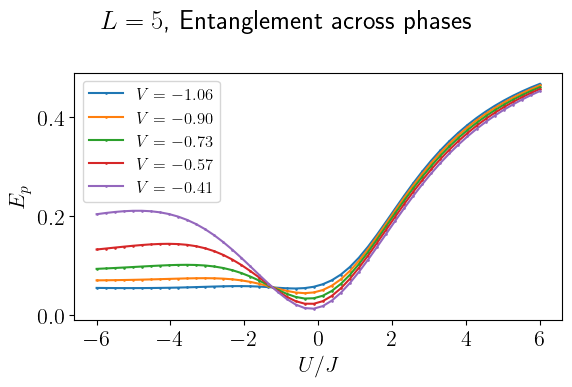

In [269]:
V_targets = [-1.53, -1.32, -1.12, -0.92, -0.72]

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plt.suptitle(f"$L = {L}$, Entanglement across phases")

for V_target in V_targets:
    i_V_fixed = np.argmin(np.abs(U_vals - V_target))
    ax.plot(U_vals, E_p[:, i_V_fixed], 'o-', markersize=0.9,  label=fr"$V={V_vals[i_V_fixed]:.2f}$")

# ax.set_xlim(0, 4)

ax.set_xlabel(r"$U / J$")
ax.set_ylabel(r"$E_p$")
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()